# Optimizers, Regularizers, and a Run Table

**Session 21 · companion to HW 3 Part B · nothing here is a homework answer**

Everything in this notebook is an ablation: one thing changes, everything else
is pinned. That discipline is the content — a deep-learning result that comes
from a single run with one seed is an anecdote, and the way to stop producing
anecdotes is to build the comparison table before running anything.

CPU only, seconds per run, no downloads.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("torch", torch.__version__, "| device: cpu (deliberately)")

digits = load_digits()
X = StandardScaler().fit_transform(digits.data).astype("float32")
y = digits.target.astype("int64")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=0, stratify=y_tmp)

to_t = lambda a: torch.from_numpy(a)
X_train_t, X_valid_t, X_test_t = map(to_t, (X_train, X_valid, X_test))
y_train_t, y_valid_t, y_test_t = map(to_t, (y_train, y_valid, y_test))

print(f"train {X_train.shape}  validation {X_valid.shape}  test {X_test.shape}")
print(f"{len(np.unique(y))} classes, {X.shape[1]} features")

torch 2.5.1 | device: cpu (deliberately)
train (1078, 64)  validation (359, 64)  test (360, 64)
10 classes, 64 features


## The harness

One function, used for every experiment below, so that no comparison is
contaminated by a difference in the loop. It takes a model factory and returns a
history — it deliberately does not expose a per-epoch training step, because
that is what HW 3 asks you to write.

In [2]:
def build_mlp(hidden=256, dropout=0.0, batchnorm=False):
    layers = [nn.Linear(X.shape[1], hidden)]
    if batchnorm:
        layers.append(nn.BatchNorm1d(hidden))
    layers.append(nn.ReLU())
    if dropout:
        layers.append(nn.Dropout(dropout))
    layers += [nn.Linear(hidden, hidden // 2)]
    if batchnorm:
        layers.append(nn.BatchNorm1d(hidden // 2))
    layers.append(nn.ReLU())
    if dropout:
        layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(hidden // 2, 10))
    return nn.Sequential(*layers)


def study(make_model, make_optimizer, epochs=60, batch_size=64, seed=0):
    """Train once under fixed conditions; return the history and the best state."""
    torch.manual_seed(seed)
    model = make_model()
    optimizer = make_optimizer(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    n = len(X_train_t)
    history = {"train_loss": [], "valid_loss": [], "valid_acc": []}
    best = {"valid_loss": float("inf"), "epoch": -1, "state": None}

    for epoch in range(epochs):
        model.train()
        order = torch.randperm(n)
        running = 0.0
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(X_train_t[idx]), y_train_t[idx])
            loss.backward()
            optimizer.step()
            running += loss.item() * len(idx)

        model.eval()
        with torch.no_grad():
            logits = model(X_valid_t)
            v_loss = loss_fn(logits, y_valid_t).item()
            v_acc = (logits.argmax(1) == y_valid_t).float().mean().item()

        history["train_loss"].append(running / n)
        history["valid_loss"].append(v_loss)
        history["valid_acc"].append(v_acc)

        if v_loss < best["valid_loss"]:
            best = {"valid_loss": v_loss, "epoch": epoch,
                    "state": {k: v.clone() for k, v in model.state_dict().items()}}

    return model, history, best

## 1. Optimizers, one seed each — and why that is not enough

Same model, same data, same epochs. Only the optimizer changes.

In [3]:
optimizers = {
    "SGD (lr=0.05)": lambda p: torch.optim.SGD(p, lr=0.05),
    "SGD + momentum": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9),
    "AdamW (lr=1e-3)": lambda p: torch.optim.AdamW(p, lr=1e-3),
    "RMSProp (lr=1e-3)": lambda p: torch.optim.RMSprop(p, lr=1e-3),
}

rows, curves = [], {}
for name, make_opt in optimizers.items():
    t0 = time.perf_counter()
    _, history, best = study(lambda: build_mlp(), make_opt, seed=0)
    rows.append({"optimizer": name,
                 "best valid loss": round(best["valid_loss"], 4),
                 "at epoch": best["epoch"],
                 "final valid acc": round(history["valid_acc"][-1], 4),
                 "seconds": round(time.perf_counter() - t0, 1)})
    curves[name] = history

print(pd.DataFrame(rows).to_string(index=False))

        optimizer  best valid loss  at epoch  final valid acc  seconds
    SGD (lr=0.05)           0.0744        59           0.9749      0.9
   SGD + momentum           0.0594        54           0.9777      0.4
  AdamW (lr=1e-3)           0.0750        32           0.9777      0.6
RMSProp (lr=1e-3)           0.0656        22           0.9777      0.5


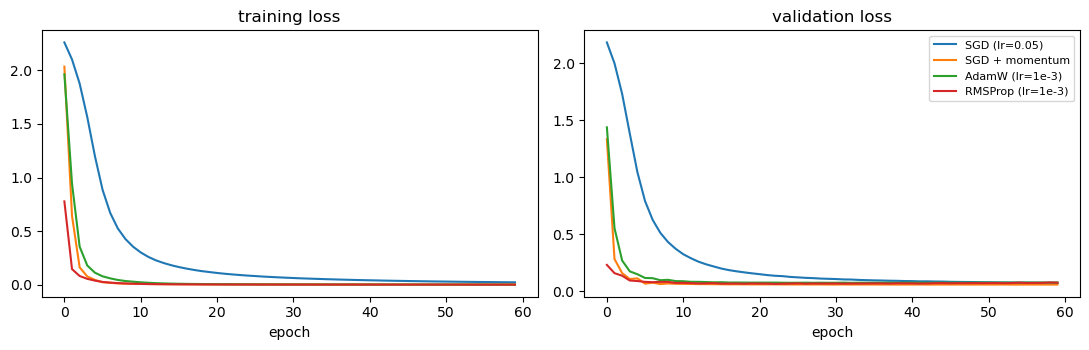

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, history in curves.items():
    axes[0].plot(history["train_loss"], label=name)
    axes[1].plot(history["valid_loss"], label=name)
axes[0].set_title("training loss"); axes[1].set_title("validation loss")
for ax in axes:
    ax.set_xlabel("epoch")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Now the part that most write-ups skip. Repeat the two headline optimizers across
several seeds and look at the spread before believing the ranking.

In [5]:
spread = []
for name in ("SGD + momentum", "AdamW (lr=1e-3)"):
    losses = [study(lambda: build_mlp(), optimizers[name], epochs=40, seed=s)[2]["valid_loss"]
              for s in range(5)]
    spread.append({"optimizer": name, "mean": round(float(np.mean(losses)), 4),
                   "std": round(float(np.std(losses)), 4),
                   "min": round(min(losses), 4), "max": round(max(losses), 4)})
print(pd.DataFrame(spread).to_string(index=False))
print("\nIf the gap between the means is smaller than these standard deviations,")
print("the ranking from a single seed was a coin flip.")

      optimizer   mean    std    min    max
 SGD + momentum 0.0697 0.0061 0.0597 0.0782
AdamW (lr=1e-3) 0.0702 0.0083 0.0564 0.0777

If the gap between the means is smaller than these standard deviations,
the ranking from a single seed was a coin flip.


## 2. Dropout and batch norm, as ablations

Same optimizer (AdamW), same epochs, one architectural change at a time.

In [6]:
variants = {
    "plain": dict(dropout=0.0, batchnorm=False),
    "dropout 0.3": dict(dropout=0.3, batchnorm=False),
    "batchnorm": dict(dropout=0.0, batchnorm=True),
    "both": dict(dropout=0.3, batchnorm=True),
}

ablation, ablation_curves = [], {}
for name, kwargs in variants.items():
    model, history, best = study(lambda k=kwargs: build_mlp(**k),
                                 optimizers["AdamW (lr=1e-3)"], seed=0)
    gap = history["valid_loss"][-1] - history["train_loss"][-1]
    ablation.append({"variant": name,
                     "final train loss": round(history["train_loss"][-1], 4),
                     "best valid loss": round(best["valid_loss"], 4),
                     "final valid acc": round(history["valid_acc"][-1], 4),
                     "generalization gap": round(gap, 4)})
    ablation_curves[name] = history

print(pd.DataFrame(ablation).to_string(index=False))

    variant  final train loss  best valid loss  final valid acc  generalization gap
      plain            0.0004           0.0750           0.9777              0.0773
dropout 0.3            0.0060           0.0732           0.9805              0.0686
  batchnorm            0.0059           0.0417           0.9805              0.0626
       both            0.0078           0.0596           0.9805              0.0603


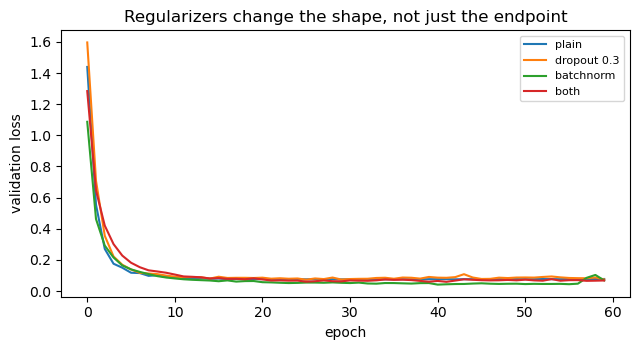

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for name, history in ablation_curves.items():
    ax.plot(history["valid_loss"], label=name)
ax.set_xlabel("epoch"); ax.set_ylabel("validation loss")
ax.set_title("Regularizers change the shape, not just the endpoint")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. `train()` and `eval()` are not cosmetic

Dropout drops units during training and does nothing at evaluation. Batch norm
uses the batch's statistics during training and its running averages afterwards.
Forget to switch, and the model you evaluate is not the model you trained.

In [8]:
model, _, best = study(lambda: build_mlp(dropout=0.3, batchnorm=True),
                       optimizers["AdamW (lr=1e-3)"], seed=0)
model.load_state_dict(best["state"])

with torch.no_grad():
    model.eval()
    correct_eval = (model(X_valid_t).argmax(1) == y_valid_t).float().mean().item()

    model.train()                      # the mistake: evaluating in training mode
    wrong = [(model(X_valid_t).argmax(1) == y_valid_t).float().mean().item() for _ in range(5)]

print(f"eval() mode : {correct_eval:.4f}   (deterministic)")
print(f"train() mode: {np.mean(wrong):.4f}  +/- {np.std(wrong):.4f}   "
      f"(five runs, five answers)")
print(f"\ncost of forgetting: {correct_eval - np.mean(wrong):+.4f} accuracy, "
      f"plus reproducibility")

eval() mode : 0.9805   (deterministic)
train() mode: 0.9716  +/- 0.0054   (five runs, five answers)

cost of forgetting: +0.0089 accuracy, plus reproducibility


## 4. Early stopping, and the checkpoint that is actually best

The harness has been recording the best validation loss all along. What matters
is that the weights kept are the ones from that epoch, not the ones the loop
happened to end on.

best epoch by validation loss: 25 of 79
validation accuracy, last epoch : 0.9749
validation accuracy, best epoch : 0.9777


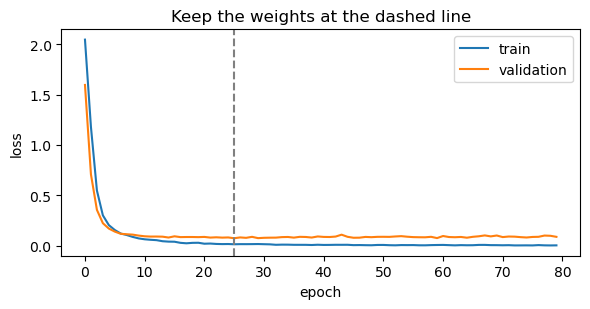

In [9]:
model, history, best = study(lambda: build_mlp(dropout=0.3),
                             optimizers["AdamW (lr=1e-3)"], epochs=80, seed=0)

final_state = {k: v.clone() for k, v in model.state_dict().items()}
model.eval()
with torch.no_grad():
    last_acc = (model(X_valid_t).argmax(1) == y_valid_t).float().mean().item()
model.load_state_dict(best["state"])
with torch.no_grad():
    best_acc = (model(X_valid_t).argmax(1) == y_valid_t).float().mean().item()

print(f"best epoch by validation loss: {best['epoch']} of {len(history['valid_loss']) - 1}")
print(f"validation accuracy, last epoch : {last_acc:.4f}")
print(f"validation accuracy, best epoch : {best_acc:.4f}")

plt.figure(figsize=(6, 3.2))
plt.plot(history["train_loss"], label="train")
plt.plot(history["valid_loss"], label="validation")
plt.axvline(best["epoch"], ls="--", color="grey")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.title("Keep the weights at the dashed line"); plt.tight_layout(); plt.show()

## 5. The run table

This is the artifact the session is really about. Every row is one experiment;
every column is either a setting or a result; the seed is recorded because
without it the row cannot be repeated.

In [10]:
table = pd.DataFrame([
    {"run": 1, "optimizer": "SGD+mom", "dropout": 0.0, "bn": False, "seed": 0},
    {"run": 2, "optimizer": "AdamW", "dropout": 0.0, "bn": False, "seed": 0},
    {"run": 3, "optimizer": "AdamW", "dropout": 0.3, "bn": False, "seed": 0},
    {"run": 4, "optimizer": "AdamW", "dropout": 0.3, "bn": True, "seed": 0},
])

results = []
for row in table.itertuples():
    make_opt = (optimizers["SGD + momentum"] if row.optimizer == "SGD+mom"
                else optimizers["AdamW (lr=1e-3)"])
    _, history, best = study(lambda: build_mlp(dropout=row.dropout, batchnorm=row.bn),
                             make_opt, epochs=60, seed=row.seed)
    results.append({"best valid loss": round(best["valid_loss"], 4),
                    "best epoch": best["epoch"],
                    "valid acc at best": round(max(history["valid_acc"]), 4)})

run_table = pd.concat([table, pd.DataFrame(results)], axis=1)
print(run_table.to_string(index=False))

winner = run_table.loc[run_table["best valid loss"].idxmin()]
print(f"\nchosen: run {int(winner.run)} ({winner.optimizer}, dropout {winner.dropout}, "
      f"bn {winner.bn})")

 run optimizer  dropout    bn  seed  best valid loss  best epoch  valid acc at best
   1   SGD+mom      0.0 False     0           0.0594          54             0.9777
   2     AdamW      0.0 False     0           0.0750          32             0.9777
   3     AdamW      0.3 False     0           0.0732          25             0.9805
   4     AdamW      0.3  True     0           0.0596          41             0.9861

chosen: run 1 (SGD+mom, dropout 0.0, bn False)


Look at run 1 against run 4. Run 1 has the lowest validation *loss*; run 4 has
the highest validation *accuracy*. They are not the same criterion and they do
not have to agree — a model can be more often right while being more confidently
wrong when it errs. Decide which one you are selecting on **before** you look at
the table, write it down, and stick to it. Here the criterion is validation loss.

## 6. The test set, once

In [11]:
make_opt = (optimizers["SGD + momentum"] if winner.optimizer == "SGD+mom"
            else optimizers["AdamW (lr=1e-3)"])
model, _, best = study(lambda: build_mlp(dropout=winner.dropout, batchnorm=winner.bn),
                       make_opt, epochs=60, seed=int(winner.seed))
model.load_state_dict(best["state"])
model.eval()
with torch.no_grad():
    test_acc = (model(X_test_t).argmax(1) == y_test_t).float().mean().item()

print(f"validation accuracy (used for selection): {winner['valid acc at best']:.4f}")
print(f"test accuracy (used once, now)          : {test_acc:.4f}")
from pathlib import Path

torch.save(model.state_dict(), "best_mlp.pt")
print(f"\nsaved a state_dict ({Path('best_mlp.pt').stat().st_size // 1024} KB), "
      f"not a pickled model object — see Session 29.")
Path("best_mlp.pt").unlink()

validation accuracy (used for selection): 0.9777
test accuracy (used once, now)          : 0.9694

saved a state_dict (201 KB), not a pickled model object — see Session 29.


## What to take from this

- Pin everything except the thing you are studying. The harness above exists so
  that no comparison differs by accident.
- One seed is one sample. Report the spread, or say plainly that you did not
  measure it.
- Dropout and batch norm change training dynamics, not just the final number —
  read the curve, not the endpoint.
- `model.eval()` is not a formality; forgetting it costs accuracy and
  reproducibility at once.
- Keep the checkpoint from the best epoch, not the last one.
- The run table, with seeds, is the deliverable. Without it, none of the above
  can be repeated.

## Where to go next

- **Reading, Session 21** — optimizers, weight decay, dropout, batch norm, and a
  tuning workflow that terminates.
- **`01_pytorch_mlp.ipynb`** — the baseline loop this notebook varies.
- **HW 3 Part B** — asks for the per-epoch training step this notebook keeps
  inside its harness.